# Ajuste de taxas de transfência não radiativa 

O sistema de EDO que contém os parâmetros de interesse é

\begin{equation}
\begin{aligned}
    \dot{n}_5
    &=
    \sigma P F(t)\, n_4
    - W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{54} n_5 
    \\
     \dot{n}_4
    &= -\dot{n_5} 
    \\
    \dot{n}_3
    &=
    W_{52} n_2 n_5
    - k_{31} n_3 
    \\
    \dot{n}_2
    &=
    W_{51} n_1 n_5
    - W_{52} n_2 n_5
    - k_{21} n_2 \\
    \dot{n}_1 &= -(\dot{n}_2 + \dot{n}_3)    
\end{aligned} .
\end{equation}

Adimensionalizando a concentração por $n_0 = n_1(0) + n_4(0)$ e o tempo por $\tau = 1/f$, obtemos

\begin{aligned}
\dot{x_5}(\tau)
&=
\Pi F(\tau) x_4
- W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{54} x_5
\\
\dot{x_4}(\tau)
&= - \dot{x_5}
\\
\dot{x_3}(\tau)
&=
W'_{52} x_2 x_5
- k'_{31} x_3 \\
\dot{x_2}(\tau)
&=
W'_{51} x_5
- W'_{52} x_2 x_5
- k'_{21} x_2
\\
\dot{x_1}(\tau)
&= -(\dot{x_3} + \dot{x_2})
\end{aligned},
onde 

### Preâmbulo e dados experimentais

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from random import random
import os

# from treament_tcspc_data import fetch_data_filenames, extract_data_info_from_path, time_domain_visual_verification
# from snr_aux_functions import get_snr_db, plot_time_and_freq_domain

In [2]:
# Phase difference list, processed previously
pd_list = np.load("./phase_difference_list.npy")

In [3]:
#--------------------------------------
# Estimations of n1 and n4
#--------------------------------------
dens_y2o3 = 5.010 #g/cm^3
massa_molar_y2o3 = 225.81 #g/mol
frac_er = 0.005 # Er3+ percentage in the sample
frac_yb = 0.015 # Yb3+ percentage in the sample

n1_0 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_er) # number of Er3+ ions 
n4_0 = (dens_y2o3/massa_molar_y2o3)*(6.022e23)*2*(frac_yb) # number of Yb3+ ions

n0 = n1_0 + n4_0

In [4]:
#--------------------------------------
# Parameters
#--------------------------------------
k21 = 16.66   # s^-1, Tab. 2 em https://doi.org/10.1063/1.2739301
k31 = 17237.7 # s^-1
k54 = 1279.0  # Tab. 2 Lu0 em https://doi.org/10.1016/j.jallcom.2021.159227
sigma = 1.75e-20 # # Supporting Information, page S5, Labrador

P = 1e24 #Photons/(cm³ * s), from measurements
# P = 1e20#5.4e20    # fótons / (cm^2 * s) (baseado em 110 W/cm^2 do paper de Labrador)

#====================================================
# Some constants
#====================================================
# ww51 = 1e-10#8.192933479247868e-09 # chute incial
# ww52 = 1e-10#1.9970817793515877e-07 # chute inicial
#====================================================

#====================================================
# Excitation modulation paramenters
#====================================================
amplitude = 0.5
offset = 0.5
#====================================================


In [5]:
# 3. Função para Extrair a Fase via FFT
def extrair_fase(t, n3, freq):
    # DICA CRUCIAL: Descartar a primeira metade da simulação (o transiente)
    # Analisamos apenas a parte onde a onda já estabilizou
    meio = len(t) // 2
    t_estavel = t[meio:]
    n3_estavel = n3[meio:]
    
    # Recria o sinal do laser no mesmo intervalo de tempo para comparação
    laser_estavel = offset + amplitude * np.cos(2 * np.pi * freq * t_estavel)
    
    N = len(t_estavel)
    dt = t_estavel[1] - t_estavel[0]
    
    # Aplica a FFT
    yf_n3 = fft(n3_estavel)
    yf_laser = fft(laser_estavel)
    xf = fftfreq(N, dt)
    
    # Encontra o índice da frequência de modulação (freq) no array da FFT
    idx = np.argmin(np.abs(xf - freq))
    
    # Extrai o ângulo (fase) de ambos os sinais nesse pico de frequência
    fase_n3 = np.angle(yf_n3[idx])
    fase_laser = np.angle(yf_laser[idx])
    
    # Diferença de fase (Luminescência - Laser)
    delta_fase = fase_n3 - fase_laser
    
    # Garante que o valor fique no intervalo correto [-pi, pi]
    delta_fase = np.angle(np.exp(1j * delta_fase))
    
    return delta_fase

adj_ph = lambda x: (180/np.pi)*np.abs(x)

# Ajustando novos parâmetros
wp51 = lambda f, W51: W51*n0/f
wp52 = lambda f, W52: W52*n0/f
kp21 = lambda f: k21/f
kp31 = lambda f: k31/f
kp45 = lambda f: sigma*P/f
kp54 = lambda f: k54/f


In [6]:
def odes(t, x, W51, W52, freq):
    # The 't' here represents the dimensionless variable tau (tau = t*f)
    x1, x2, x3, x4, x5 = x

    # Laser function according to previously defined settings
    F_t = offset + amplitude * np.cos(2 * np.pi * t)

    # Numerical safeguard: intensity cannot be negative.
    if F_t < 0: F_t = 0.0 

    # Yb3+ populations    
    dx5_dt = kp45(freq) * F_t * x4 - wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kp54(freq) * x5
    dx4_dt = -dx5_dt

    # Er3+ populations
    dx3_dt = wp52(freq, W52) * x5 * x2 - kp31(freq) * x3
    dx2_dt = wp51(freq, W51) * x5 * x1 - wp52(freq, W52) * x5 * x2 - kp21(freq) * x2 
    dx1_dt = -(dx3_dt + dx2_dt) 
    
    return [dx1_dt, dx2_dt, dx3_dt, dx4_dt, dx5_dt]

### Ajuste numérico

In [7]:
def funcao_custo(parametros_escalonados, freq_exp, fase_exp):
    # 1. Reverte o escalonamento: multiplica o valor do otimizador pela ordem de grandeza real
    ESCALA = 1e-16
    W51 = parametros_escalonados[0] * ESCALA
    W52 = parametros_escalonados[1] * ESCALA
    
    fases_calculadas = []
    
    for f in freq_exp:
        # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
        t_span = (0, 200) 
        t_eval = np.linspace(t_span[0], t_span[1], 10000)
        
        sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, f), 
            method='Radau'
        )
        
        # Converte de volta para unidades físicas antes de extrair a fase
        n3 = (sol.y[2]) * n0 
        ts = (sol.t) * (1/f) 
        
        fase_calc = extrair_fase(ts, n3, f)
        fases_calculadas.append(fase_calc)
        
    # 2. Evita descontinuidades artificiais (saltos de fase)
    fases_calculadas = np.unwrap(np.array(fases_calculadas))
    
    # IMPORTANTE: Garanta que a fase_exp também não possua saltos antes de entrar na funcao_custo!
    # Se necessário, descomente a linha abaixo caso a fase_exp ainda não tenha passado pelo unwrap:
    # fase_exp = np.unwrap(fase_exp)
    
    # O Least Squares minimizará a diferença entre os arrays
    return fases_calculadas - fase_exp

In [8]:
# initial_values = [[random()*1e-10, random()*1e-10 ]]
# initial_values = [[(2*i + random())*10**(-16), (2*i + random())*10**(-16)] for i in range(5)]

In [9]:
# =====================================================================
# GERAÇÃO DE PALPITES LOGARÍTMICOS (ESCALONADOS)
# =====================================================================
# Como nosso fator de escala é 1e-16, o valor 1.0 aqui equivale a 1e-16 fisicamente.
# np.logspace(-1, 1, 3) vai gerar o array: [0.1, 1.0, 10.0]
w51_chutes_escalonados = np.logspace(-1, 1, 3) 
w52_chutes_escalonados = np.logspace(-1, 1, 3)

initial_values = [[w1, w2] for w1 in w51_chutes_escalonados for w2 in w52_chutes_escalonados]

# =====================================================================
# 5. EXECUÇÃO DO AJUSTE
# =====================================================================
w_list = []
skip_fitting = False
save_data = True
num_points = 23
ESCALA = 1e-10

for chute_inicial in initial_values:
    if skip_fitting: continue

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 
        
        print("-" * 30)
        print(f"Iniciando ajuste numérico para a partícula {p_id + 1}...")
        print(f"Chute inicial (escala Otimizador): {chute_inicial}")

        # Roda o otimizador
        resultado = least_squares(
            funcao_custo, 
            chute_inicial, 
            args=(frequencias_experimentais, fases_experimentais),
            bounds=(0, np.inf), 
            method='trf',
            x_scale='jac'
        )

        # 3. Refaz o escalonamento para salvar os valores FÍSICOS reais
        W51_fisico = resultado.x[0] * ESCALA
        W52_fisico = resultado.x[1] * ESCALA

        w_list.append([W51_fisico, W52_fisico, resultado.cost])

        print("AJUSTE CONCLUÍDO!")
        print(f"W51 encontrado = {W51_fisico:.3e} cm³/s")
        print(f"W52 encontrado = {W52_fisico:.3e} cm³/s")
        print(f"custo = {resultado.cost:.4e} ")
        print("-" * 30)

# ======================
# Save the fitted data
# ======================

w_list = np.array(w_list)
if save_data: np.save(f"w_list_{ESCALA}", w_list)

------------------------------
Iniciando ajuste numérico para a partícula 1...
Chute inicial (escala Otimizador): [np.float64(0.1), np.float64(0.1)]
AJUSTE CONCLUÍDO!
W51 encontrado = 1.000e-11 cm³/s
W52 encontrado = 1.000e-11 cm³/s
custo = 5.3583e+00 
------------------------------
------------------------------
Iniciando ajuste numérico para a partícula 1...
Chute inicial (escala Otimizador): [np.float64(0.1), np.float64(1.0)]
AJUSTE CONCLUÍDO!
W51 encontrado = 1.000e-11 cm³/s
W52 encontrado = 1.000e-10 cm³/s
custo = 4.9809e+00 
------------------------------
------------------------------
Iniciando ajuste numérico para a partícula 1...
Chute inicial (escala Otimizador): [np.float64(0.1), np.float64(10.0)]
AJUSTE CONCLUÍDO!
W51 encontrado = 1.000e-11 cm³/s
W52 encontrado = 1.000e-09 cm³/s
custo = 4.8457e+00 
------------------------------
------------------------------
Iniciando ajuste numérico para a partícula 1...
Chute inicial (escala Otimizador): [np.float64(1.0), np.float64(0.1)

#### Plot results

In [10]:
# w_list = np.load("./w_list.npy")
# w_list_16 = np.load("./w_list_1e-16.npy")

In [11]:
init_val_res = [[w_list[i][0], w_list[i][1]] for i in range(len(w_list))]
# init_val_res = [[random()*1e-14, random()*1e-15]]

print(init_val_res)

[[np.float64(1.0000000000000001e-11), np.float64(1.0000000000000001e-11)], [np.float64(1.000030152117566e-11), np.float64(9.999668057971879e-11)], [np.float64(1.0000000004557078e-11), np.float64(9.99999138423911e-10)], [np.float64(1.0000000024340228e-10), np.float64(9.999866999988948e-12)], [np.float64(1.0004795455761109e-10), np.float64(9.998142440774407e-11)], [np.float64(9.999669651938772e-11), np.float64(1.0003384689558889e-09)], [np.float64(1e-09), np.float64(1.0000000000000001e-11)], [np.float64(9.999432678240845e-10), np.float64(1.0000474731985818e-10)], [np.float64(1e-09), np.float64(1e-09)]]


(1.000e-11, 1.000e-11)


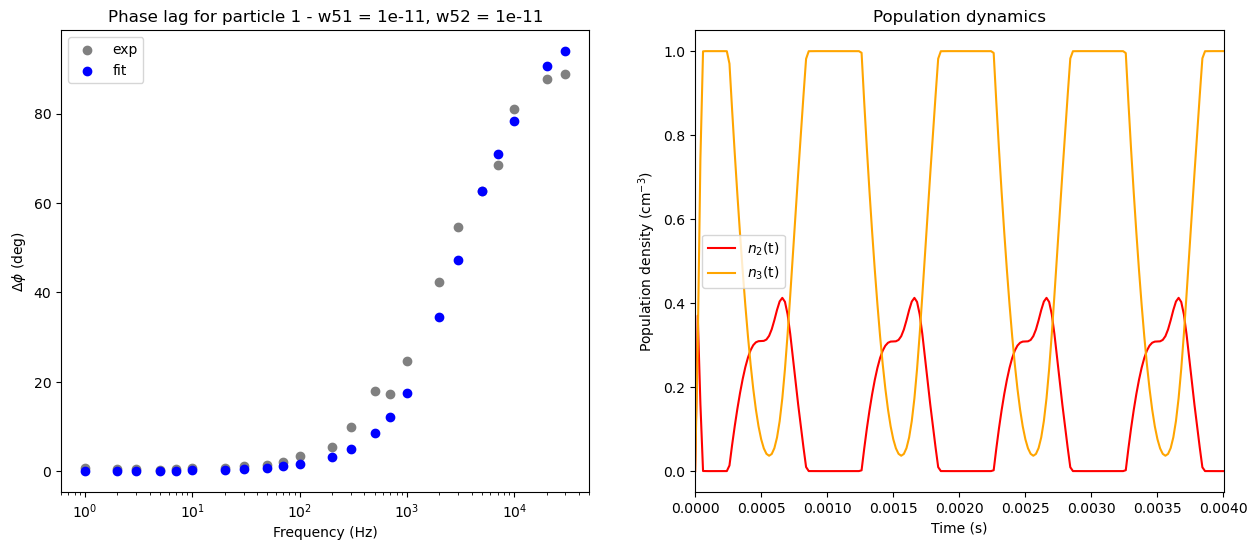

(1.000e-11, 1.000e-10)


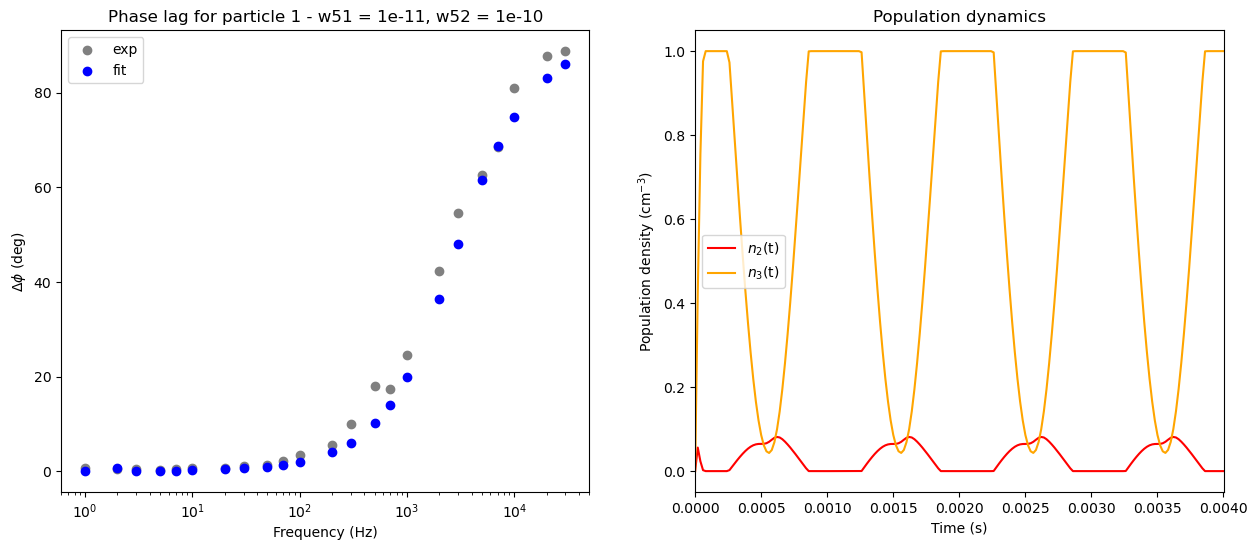

(1.000e-11, 1.000e-09)


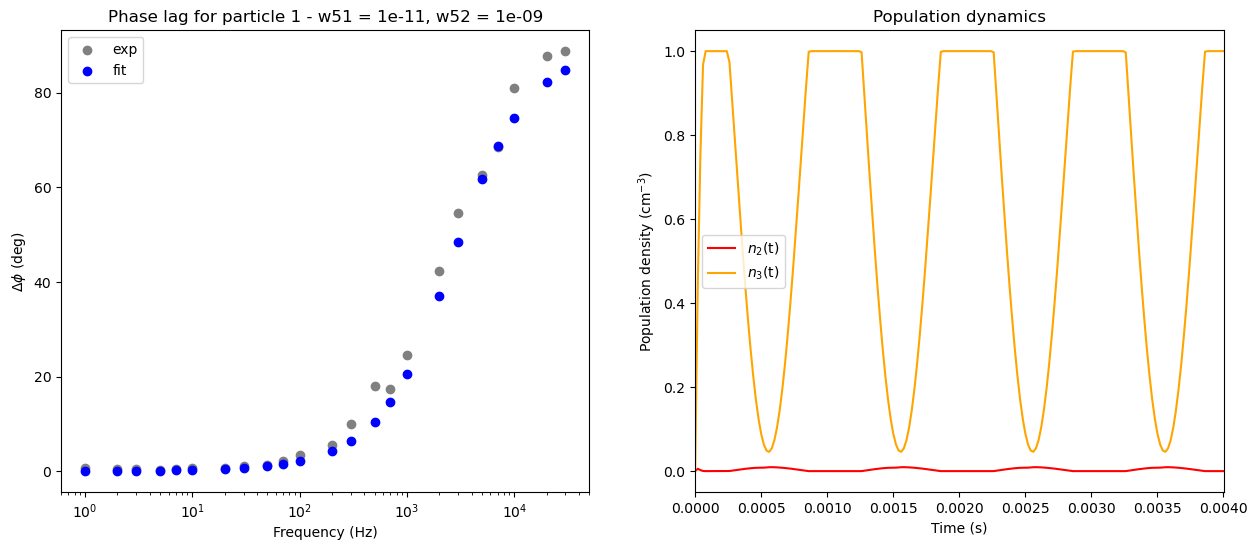

(1.000e-10, 1.000e-11)


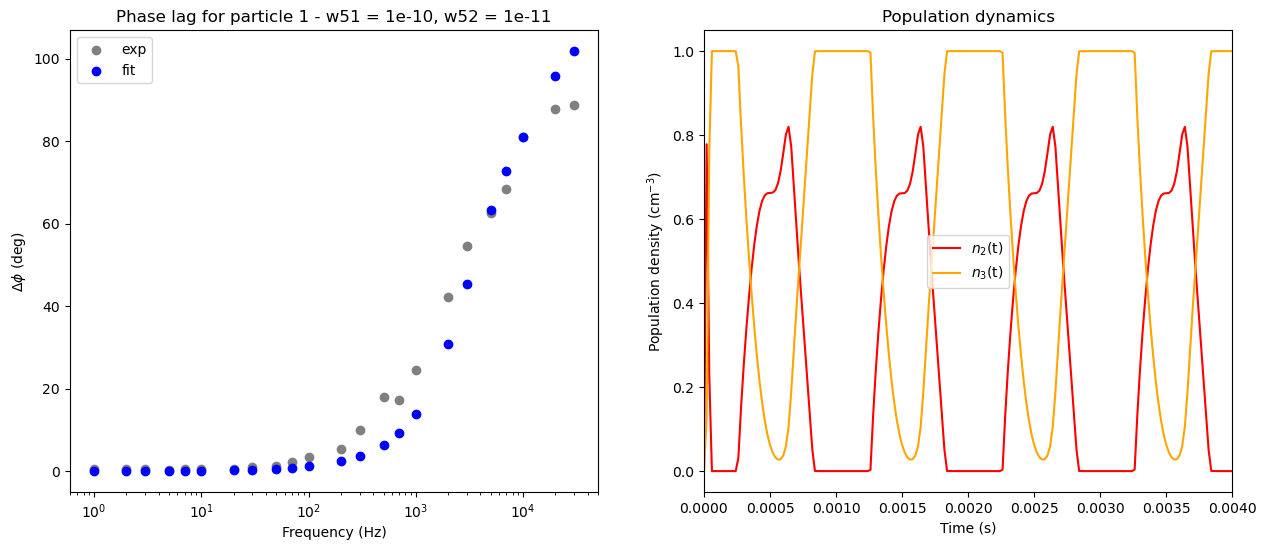

(1.000e-10, 9.998e-11)


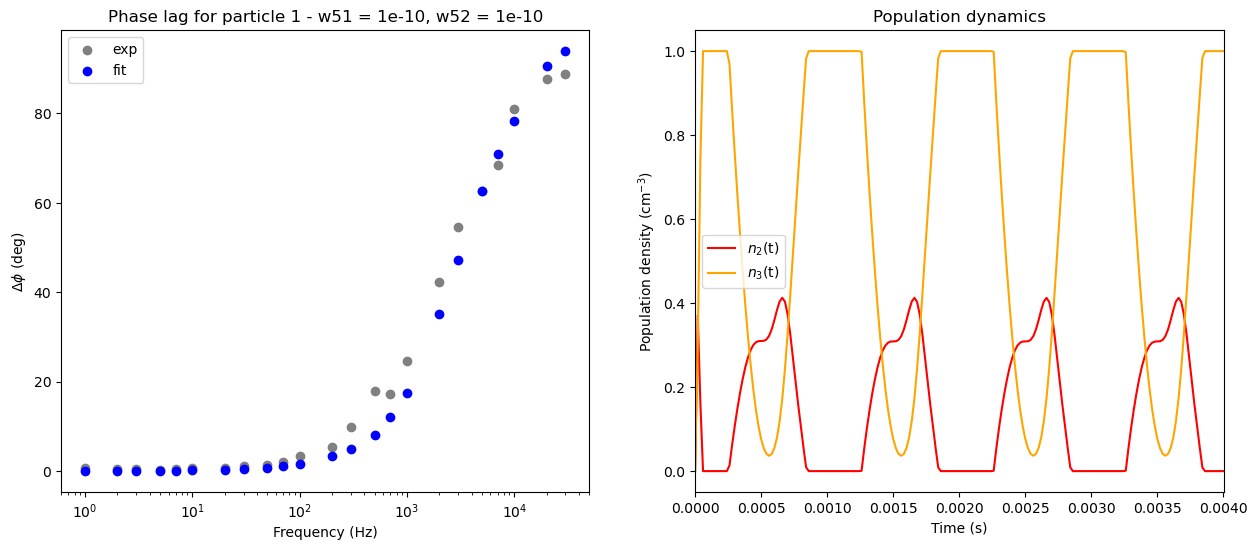

(1.000e-10, 1.000e-09)


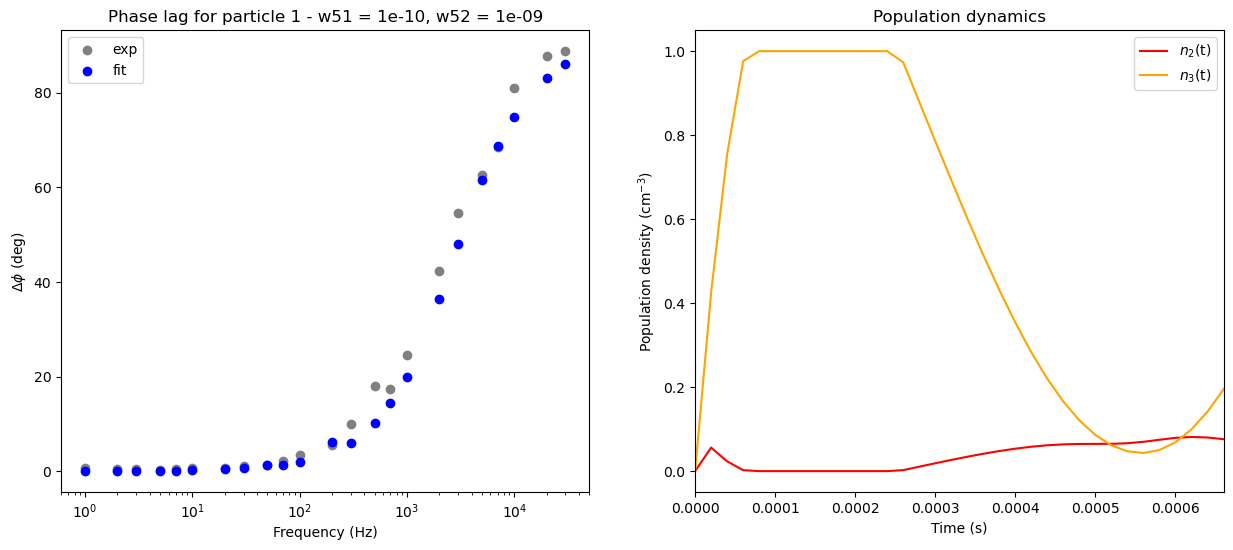

(1.000e-09, 1.000e-11)


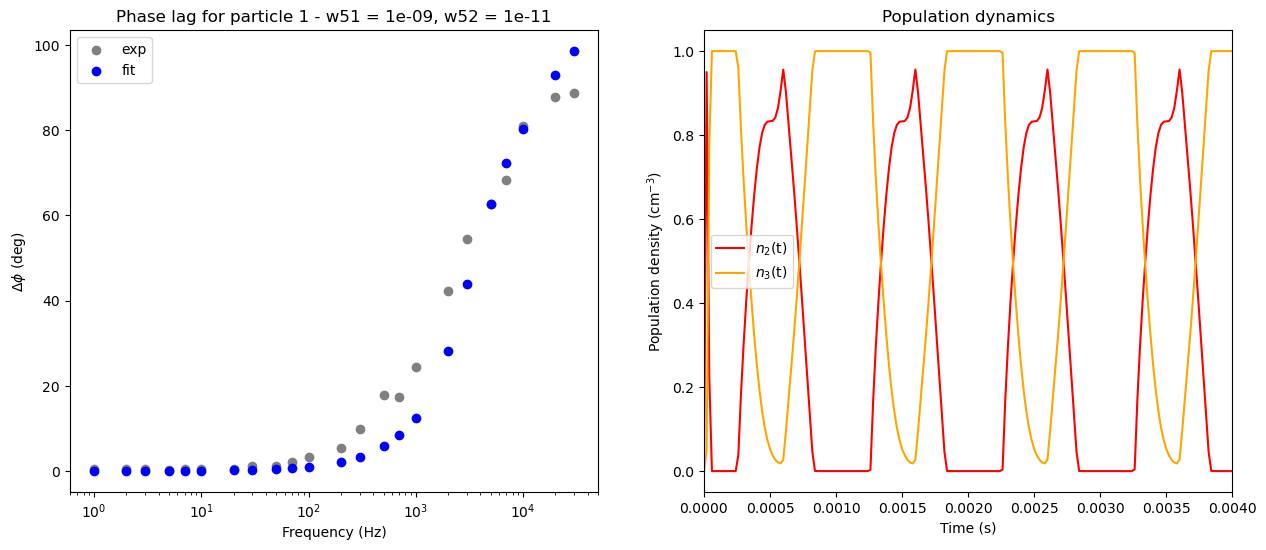

(9.999e-10, 1.000e-10)


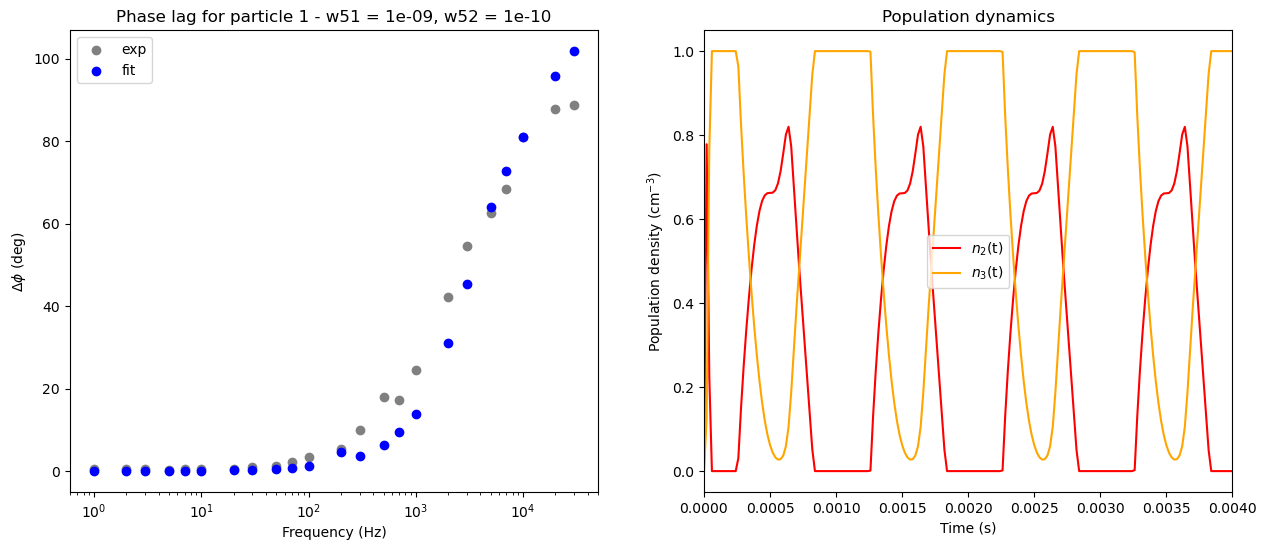

(1.000e-09, 1.000e-09)


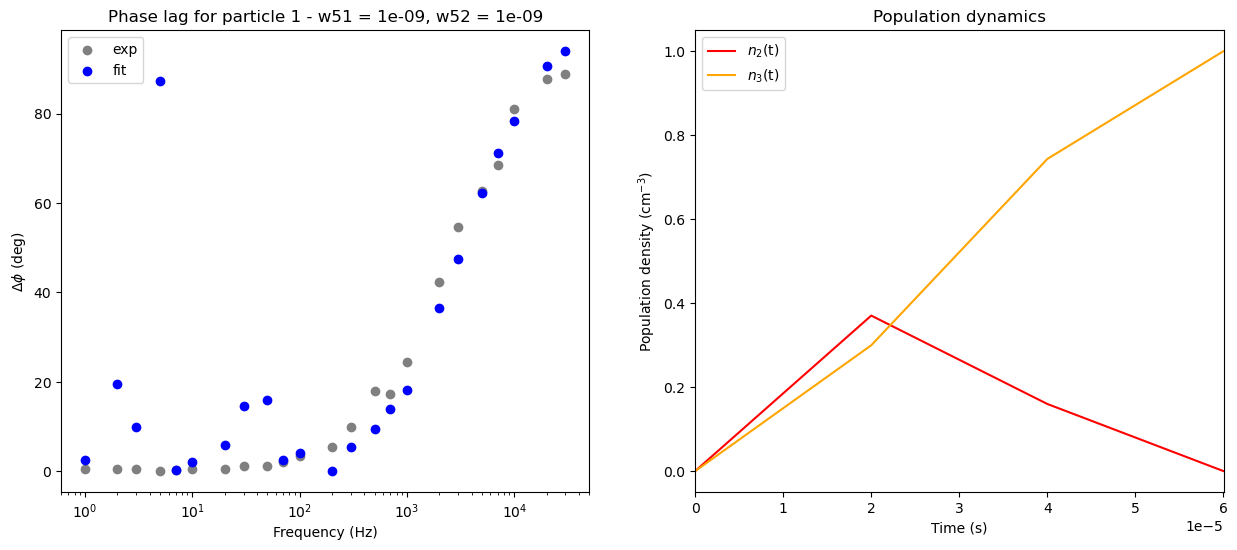

In [12]:

for iv_idx, iv in enumerate(init_val_res):
    # if iv_idx !=0: continue

    fases_calculadas = []
    print(f"({iv[0]:.3e}, {iv[1]:.3e})")

    for p_id, pd in enumerate(pd_list):
        if p_id != 0: continue
        frequencias_experimentais = pd[:num_points, 0] 
        fases_experimentais = pd[:num_points, 1] 

        W51, W52 = iv[0], iv[1]
        # W51, W52 = random()*1e-14, random()*1e-15

        sol_to_plot = []
        
        for f in frequencias_experimentais:
            # Simula 200 ciclos em tempo adimensional para garantir que o transiente morra
            t_span = (0, 200) 
            t_eval = np.linspace(t_span[0], t_span[1], 10000)

            sol = solve_ivp(
            odes, 
            t_span, 
            [n1_0/n0, 0, 0, n4_0/n0, 0], #x1 x2 x3 x4 x5 @ t=0
            t_eval=t_eval,
            args=(W51, W52, f), 
            method='Radau' # Mantendo o método Radau que demonstrou estabilidade acima
            )

            # Converte de volta para unidades físicas antes de extrair a fase
            n3 = (sol.y[2]) * n0 
            ts = (sol.t) * (1/f)

            n2 = (sol.y[1]) * n0 
            n11 = (sol.y[0]) * n0 

            if f == 1000:
                sol_to_plot = [ts, n11, n2, n3]

            # plt.plt(ts, n11)

            fase_calc = extrair_fase(ts, n3, f)
            fases_calculadas.append(fase_calc)

        fases_calculadas = np.unwrap(np.array(fases_calculadas))

        fig, axs = plt.subplots(1, 2, figsize=(15, 6))
        #Phase lag plot
        axs[0].scatter(frequencias_experimentais, adj_ph(fases_experimentais), color="gray", label="exp")
        axs[0].scatter(frequencias_experimentais, adj_ph(fases_calculadas), color="blue", label="fit")
        axs[0].set_xscale("log")
        axs[0].set_ylabel("$\Delta \phi$ (deg)")
        axs[0].set_xlabel("Frequency (Hz)")
        axs[0].set_title(f"Phase lag for particle 1 - w51 = {W51:.3}, w52 = {W52:.3}")
        axs[0].legend()
        
        #Population time evolution @ 1kHz
        ts, n11, n2, n3 = sol_to_plot
        # axs[1].plot(ts, n11/n11.max(), color="lightblue", label="$n_1$(t)")
        axs[1].plot(ts, n2/n11.max(), color="red", label="$n_2$(t)")
        axs[1].plot(ts, n3/n11.max(), color="orange", label="$n_3$(t)")
        # axs[1].set_xscale("log")
        axs[1].set_ylabel("Population density (cm$^{-3}$)")
        axs[1].set_xlabel("Time (s)")
        axs[1].set_xlim([0,ts[int(len(ts)*(0.02))]])
        axs[1].set_title(f"Population dynamics")
        axs[1].legend()

        #-------------------------------------------------------------
        # Save plots
        #-------------------------------------------------------------
        ESCALA_str = f"{ESCALA:.2e}".replace('.', '_')
        W51_str = f"{W51:.2e}".replace('.', '_')
        W52_str = f"{W52:.2e}".replace('.', '_')
        os.makedirs(f"./figs_scale{ESCALA_str}", exist_ok=True)
        plt.savefig(
            f"./figs_scale{ESCALA_str}/fig_{iv_idx + 1}__w51_{W51_str}__w52_{W52_str}.png",
            dpi=300, bbox_inches="tight"
        )
        #-------------------------------------------------------------

        plt.show()
